In [1]:
from fdip import FDIP

In [2]:
p = FDIP("slagheap_corr")
print(p)

17/08/26 - 07:38:04 - pyGIMLi - INFO - filtering: nd=696, nf=9
17/08/26 - 07:38:04 - pyGIMLi - INFO - Sum(ind): 696
17/08/26 - 07:38:04 - pyGIMLi - INFO - filtered: nd=696, nf=9


SIP data: nf=9 nc=0 nv=59 Data: Sensors: 40 data: 696, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


In [3]:
p.loadResults(loadFit=True)

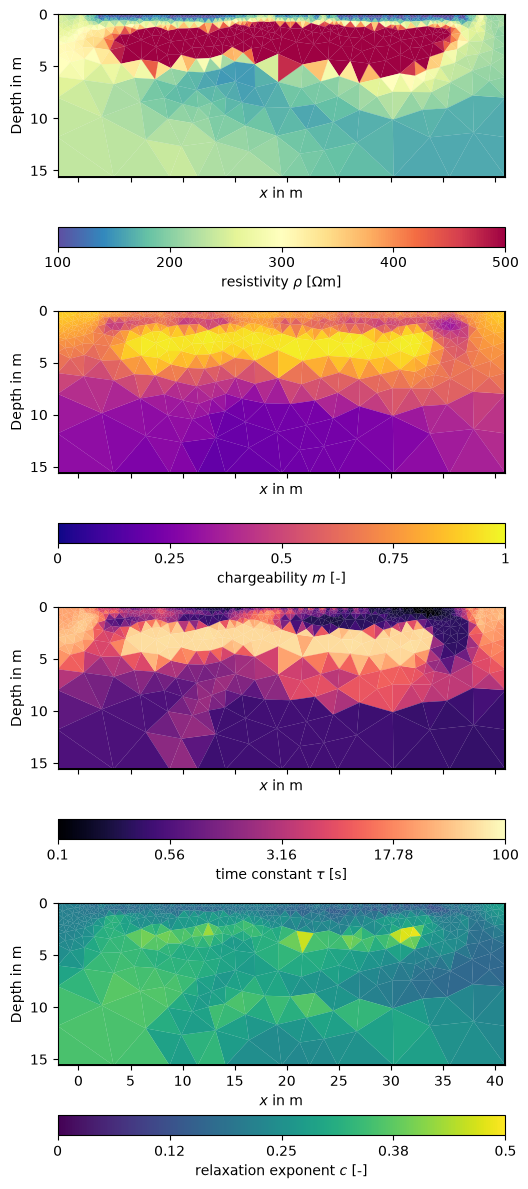

In [5]:
p.showColeColeParameters(rlim=(100, 500), mlim=(0, 1), tlim=(0.1, 100),
                         coverage=1);

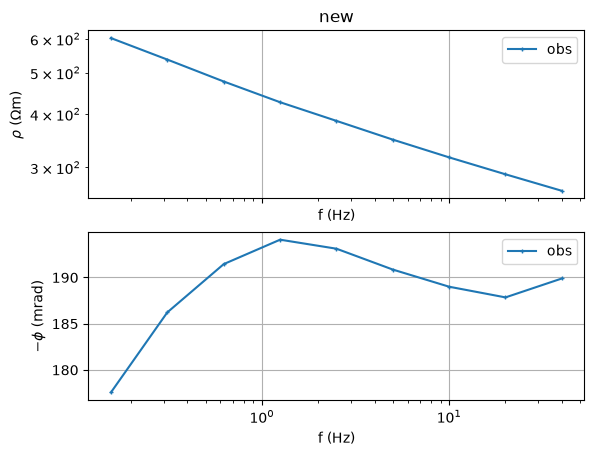

In [6]:
spec = p.getModelSpectrum([23, -2.5])
spec.showData();

[0 1 2]
[3 4 5]
[6 7 8]


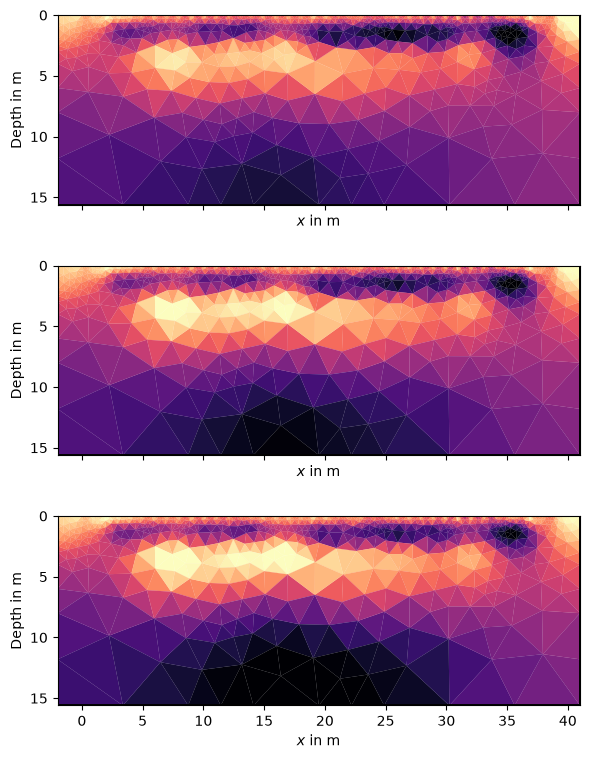

In [7]:
import numpy as np
import matplotlib.pyplot as plt
res = np.median(p.RES, axis=1)
fi = np.nonzero(p.freq < 1.0)[0]
print(fi)
sLow = np.mean(np.sin(p.PHI[:, fi]) / p.RES[:, fi], axis=1)
fi = np.nonzero((p.freq >= 1.0)&(p.freq < 10.0))[0]
print(fi)
sMid = np.mean(np.sin(p.PHI[:, fi]) / p.RES[:, fi], axis=1)
fi = np.nonzero(p.freq >= 10.0)[0]
print(fi)
sHigh = np.mean(np.sin(p.PHI[:, fi]) / p.RES[:, fi], axis=1)
fig, ax = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6, 8))
kw = dict(cMin=0.1, cMax=3, logScale=True, cMap="magma", colorBar=False)
p.pd.show(sLow*1e3, ax=ax[0], **kw)
p.pd.show(sMid*1e3, ax=ax[1], **kw)
p.pd.show(sHigh*1e3, ax=ax[2], **kw);